In [ ]:
import numpy as np
import pandas as pd
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from google.colab import files
upload = files.upload()

Saving amazon_cells_labelled.csv to amazon_cells_labelled.csv


In [ ]:
reviews = pd.read_csv("amazon_cells_labelled.csv")

In [ ]:
reviews.head()

,Text,Sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [ ]:
reviews['Sentiment'].value_counts()
label= reviews['Sentiment']

In [ ]:
text1 = []

In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(reviews['Sentiment'])
print(label[:10])
print(reviews['Sentiment'][:10])

[0 1 1 0 1 0 0 1 0 0]
0    0
1    1
2    1
3    0
4    1
5    0
6    0
7    1
8    0
9    0
Name: Sentiment, dtype: int64


In [ ]:
#change the text column datatype to string
reviews = reviews.astype({'Text':'string'})

In [ ]:
reviews.dtypes

Text         string
Sentiment     int64
dtype: object

In [ ]:
#get the review text for preprocessing
text = reviews['Text']
text[:5]

0    So there is no way for me to plug it in here i...
1                          Good case, Excellent value.
2                               Great for the jawbone.
3    Tied to charger for conversations lasting more...
4                                    The mic is great.
Name: Text, dtype: string

In [ ]:
for review in text:
    #print(sentence)
    #remove punctuation
    review = review.translate(str.maketrans('', '', string.punctuation))
    # remove digits/numbers
    review = review.translate(str.maketrans('', '', string.digits))
    #change to lowercase
    review = review.lower()
    #print(sentence)
    text1.append(review)


text1[:5]

['so there is no way for me to plug it in here in the us unless i go by a converter',
 'good case excellent value',
 'great for the jawbone',
 'tied to charger for conversations lasting more than  minutesmajor problems',
 'the mic is great']

In [ ]:
text1 = pd.Series(text1)
text1[:5]

0    so there is no way for me to plug it in here i...
1                            good case excellent value
2                                great for the jawbone
3    tied to charger for conversations lasting more...
4                                     the mic is great
dtype: object

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#remove stop words

#Setting English stopwords
stop_words = set(stopwords.words('english'))

text1 = text1.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))
text1[:5]

0                      way plug us unless go converter
1                            good case excellent value
2                                        great jawbone
3    tied charger conversations lasting minutesmajo...
4                                            mic great
dtype: object

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#apply lemmatising
from nltk.stem import WordNetLemmatizer

# Init the Wordnet Lemmatizer
lemmatizer = WordNetLemmatizer()
text2 = text1.apply(lambda x:' '.join(lemmatizer.lemmatize(w) for w in x.split()))
text2[:5] #notice that it does not do a good job

0                       way plug u unless go converter
1                            good case excellent value
2                                        great jawbone
3    tied charger conversation lasting minutesmajor...
4                                            mic great
dtype: object

from google.colab import files
files.download("NEWFILE.csv")

In [ ]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
#apply lemmatising with POS tags

from nltk.corpus import wordnet

def get_wordnet_pos(word):
    #Map POS tag to first character lemmatize() accepts
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

# Init the Wordnet Lemmatizer
lemmatizer = WordNetLemmatizer()
text3 = text1.apply(lambda x:' '.join(lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in x.split()))
text3[:5] #notice that it does a better job

0                       way plug u unless go converter
1                            good case excellent value
2                                        great jawbone
3    tie charger conversation last minutesmajor pro...
4                                            mic great
dtype: object

In [ ]:
#apply stemming
ps = nltk.PorterStemmer()

text4 = text1.apply(lambda x: ' '.join(ps.stem(term) for term in x.split()))
text4[:5]

0                    way plug us unless go convert
1                             good case excel valu
2                                     great jawbon
3    tie charger convers last minutesmajor problem
4                                        mic great
dtype: object

In [ ]:
reviews1 = list(zip(text3, label))

reviewsP = pd.DataFrame (reviews1, columns = ['Review', 'Sentiment'])
reviewsP

,Review,Sentiment
0,way plug u unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tie charger conversation last minutesmajor pro...,0
4,mic great,1
...,...,...
995,screen get smudge easily touch ear face,0
996,piece junk lose call phone,0
997,item match picture,0
998,thing disappoint infra red port irda,0


In [ ]:
#transform text into BoW with count features
cv=CountVectorizer()

#cv_reviews
cv_reviews = cv.fit_transform(reviewsP['Review'])

#see the features
cv.get_feature_names_out()

array(['abhor', 'ability', 'able', ..., 'youll', 'za', 'zero'],
      dtype=object)

In [ ]:
print(cv_reviews)

  (0, 1423)	1
  (0, 961)	1
  (0, 1373)	1
  (0, 557)	1
  (0, 270)	1
  (1, 560)	1
  (1, 186)	1
  (1, 436)	1
  (1, 1395)	1
  (2, 564)	1
  (2, 684)	1
  (3, 1313)	1
  (3, 204)	1
  (3, 269)	1
  (3, 711)	1
  (3, 810)	1
  (3, 990)	1
  (4, 564)	1
  (4, 801)	1
  (5, 961)	1
  (5, 686)	1
  (5, 549)	2
  (5, 735)	1
  (5, 1090)	1
  (5, 312)	1
  :	:
  (995, 381)	1
  (995, 1119)	1
  (995, 460)	1
  (995, 1335)	1
  (995, 392)	1
  (995, 1197)	1
  (996, 937)	1
  (996, 171)	1
  (996, 945)	1
  (996, 756)	1
  (996, 691)	1
  (997, 944)	1
  (997, 679)	1
  (997, 782)	1
  (998, 1301)	1
  (998, 344)	1
  (998, 1058)	1
  (998, 654)	1
  (998, 967)	1
  (998, 675)	1
  (999, 1468)	1
  (999, 848)	1
  (999, 171)	1
  (999, 1371)	1
  (999, 51)	1


In [ ]:
cv_reviews.shape

(1000, 1487)

In [ ]:
#to see the data in the typical tabular format
df =  pd.DataFrame(cv_reviews.toarray(), columns=cv.get_feature_names_out())
df.head()

,abhor,ability,able,abound,abovepretty,absolutel,absolutely,ac,accept,acceptable,...,wrongfirst,year,yearsgreat,yell,yes,yet,youd,youll,za,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Trasform text into Tfidf representations
tv=TfidfVectorizer()

#transformed train reviews
tv_reviews=tv.fit_transform(reviewsP['Review'])

print(tv.get_feature_names_out())

['abhor' 'ability' 'able' ... 'youll' 'za' 'zero']


In [ ]:
tv_reviews.shape

(1000, 1487)

In [ ]:
print(tv_reviews[1])

  (0, 1395)	0.6449050698342884
  (0, 436)	0.4824984034322917
  (0, 186)	0.4560027236573546
  (0, 560)	0.3786215229016904


In [ ]:
#get to top n features with the highest tf-idf
feature_names = np.array(tv.get_feature_names_out())

def get_top_tf_idf_words(tv_reviews, top_n=10):
    importance = np.argsort(np.asarray(tv_reviews.sum(axis=0)).ravel())[::-1]
    return feature_names[importance[:top_n]]

print([get_top_tf_idf_words(tv_reviews,10)])

[array(['phone', 'great', 'work', 'good', 'product', 'well', 'use',
       'headset', 'quality', 'battery'], dtype=object)]


In [ ]:
df1 =  pd.DataFrame(tv_reviews.toarray(), columns=tv.get_feature_names_out())

df1['phone'].describe()

count    1000.000000
mean        0.041017
std         0.105663
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.642676
Name: phone, dtype: float64

<Axes: >

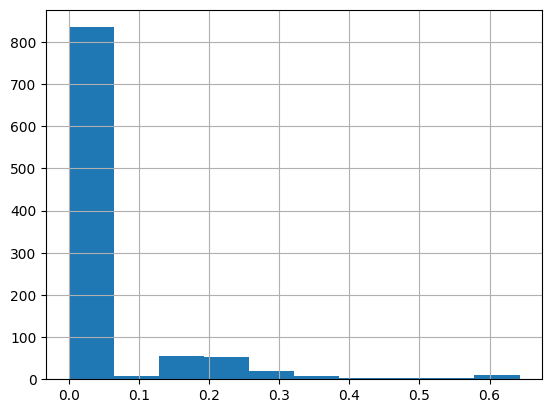

In [ ]:
df1['phone'].hist()

In [ ]:
df1['phone'].describe()

count    1000.000000
mean        0.041017
std         0.105663
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.642676
Name: phone, dtype: float64

In [ ]:
#from google.colab import files
#reviewsP.to_csv('IDTATextPreprocessing.csv')
#d = files.download("IDTATextPreprocessing.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>